# Sprint 9 — Beta Bank: Previsão de Churn

Objetivo: construir um modelo de classificação para prever se um cliente do Beta Bank vai deixar o banco. A meta é atingir F1-score de pelo menos 0.59 no conjunto de teste. Também vou medir o AUC-ROC para comparação.

## 1. Importações e carregamento dos dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score, roc_auc_score, classification_report, confusion_matrix
)

In [2]:
data = pd.read_csv('/datasets/Churn.csv')
print('Formato:', data.shape)
data.head()

Formato: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2.0,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1.0,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8.0,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1.0,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2.0,125510.82,1,1,1,79084.10,0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           9091 non-null   float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 1.1+ MB


In [4]:
print('Valores ausentes por coluna:')
print(data.isnull().sum())

Valores ausentes por coluna:
RowNumber            0
CustomerId           0
Surname              0
CreditScore          0
Geography            0
Gender               0
Age                  0
Tenure             909
Balance              0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary      0
Exited               0
dtype: int64


Observações iniciais:

- Dataset com 10.000 linhas e 14 colunas.
- A coluna Tenure tem 909 valores ausentes, cerca de 9% dos dados.
- As colunas RowNumber, CustomerId e Surname são identificadores e não trazem informação preditiva, então vou removê-las.
- Geography e Gender são categóricas e precisam de codificação.
- O target é Exited (0 = ficou, 1 = saiu).

## 2. Preparação dos dados

In [5]:
data = data.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

data['Tenure'] = data['Tenure'].fillna(data['Tenure'].median())

print('Nulos restantes:', data.isnull().sum().sum())

Nulos restantes: 0


## 3. Análise exploratória

In [6]:
data.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,4.99790,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.76001,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.00000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.00000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.00000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.00000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.00000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


0    0.7963
1    0.2037
Name: Exited, dtype: float64


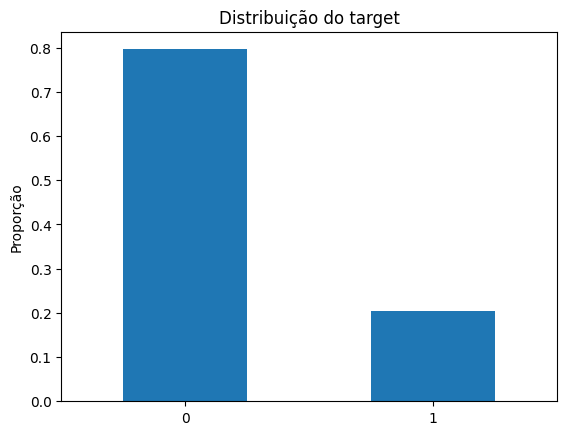

In [7]:
class_freq = data['Exited'].value_counts(normalize=True)
print(class_freq)

class_freq.plot(kind='bar', title='Distribuição do target')
plt.xticks(rotation=0)
plt.ylabel('Proporção')
plt.show()

Há desequilíbrio claro: cerca de 80% ficaram e 20% saíram. Um modelo que sempre prevê "ficou" teria 80% de acurácia mas seria inútil. Por isso o projeto exige F1-score.

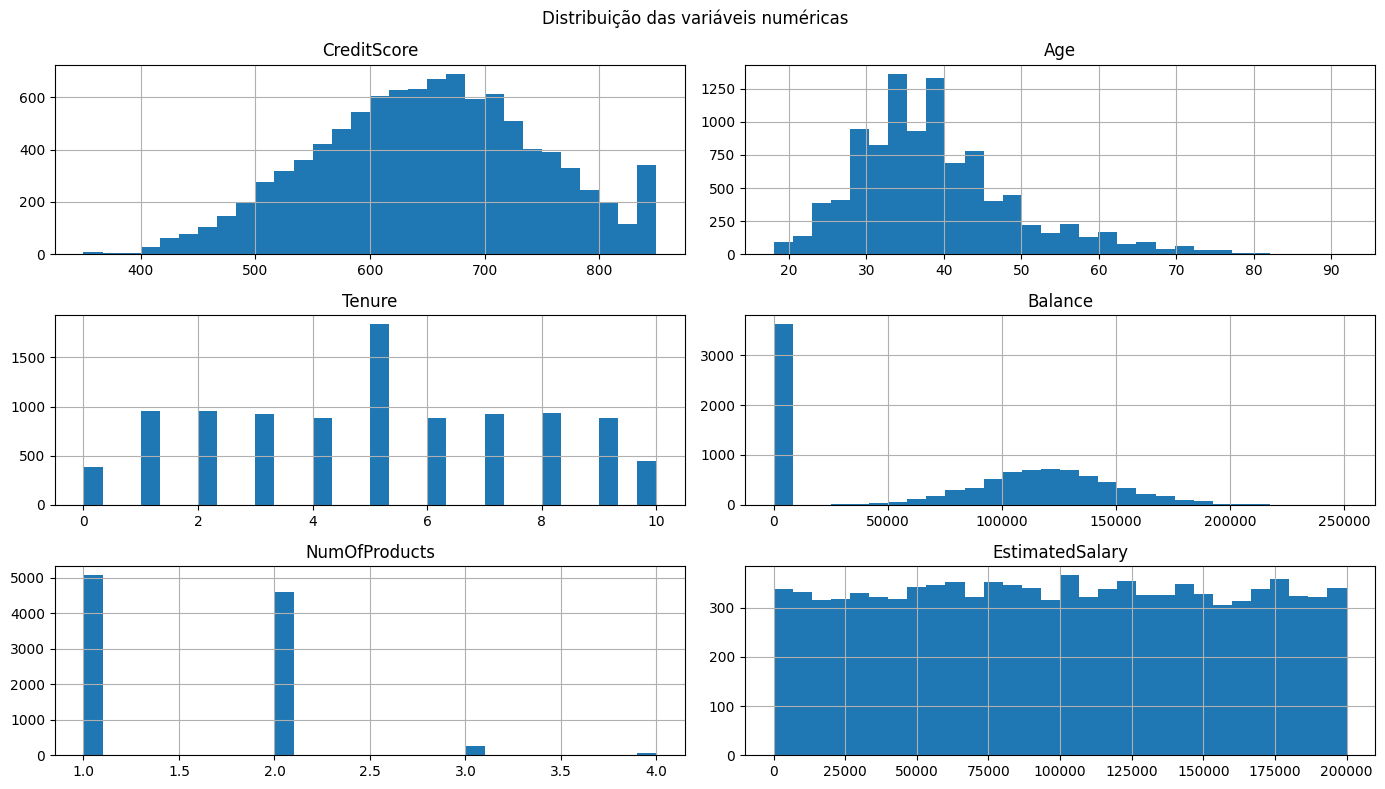

In [8]:
numeric_cols = ['CreditScore', 'Age', 'Tenure', 'Balance',
                'NumOfProducts', 'EstimatedSalary']

data[numeric_cols].hist(bins=30, figsize=(14, 8))
plt.suptitle('Distribuição das variáveis numéricas')
plt.tight_layout()
plt.show()

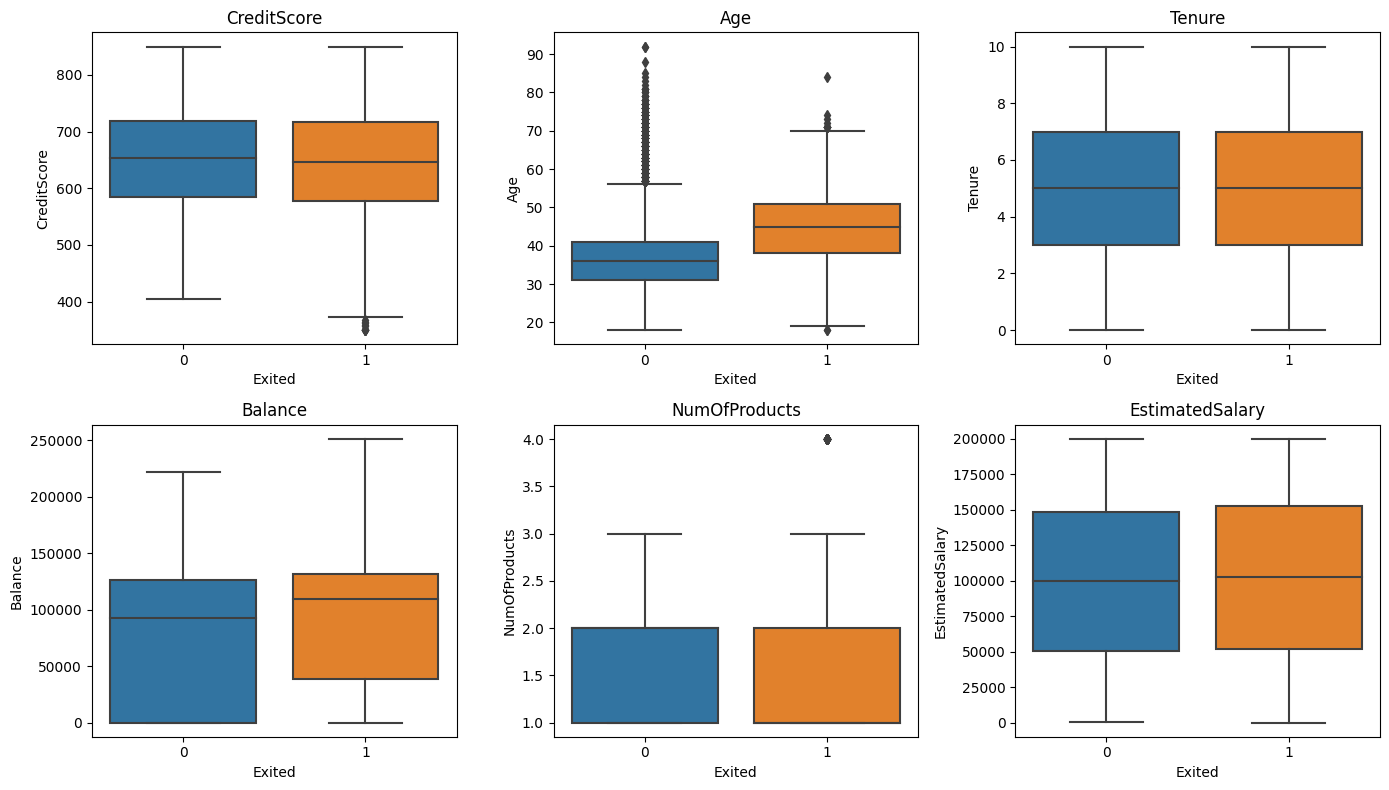

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.boxplot(x='Exited', y=col, data=data, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

Observações dos boxplots:

- Age mostra diferença marcada: clientes que saíram tendem a ser mais velhos.
- Balance também aparenta ser maior entre quem saiu.
- CreditScore, Tenure e EstimatedSalary mostram distribuições parecidas entre as duas classes.

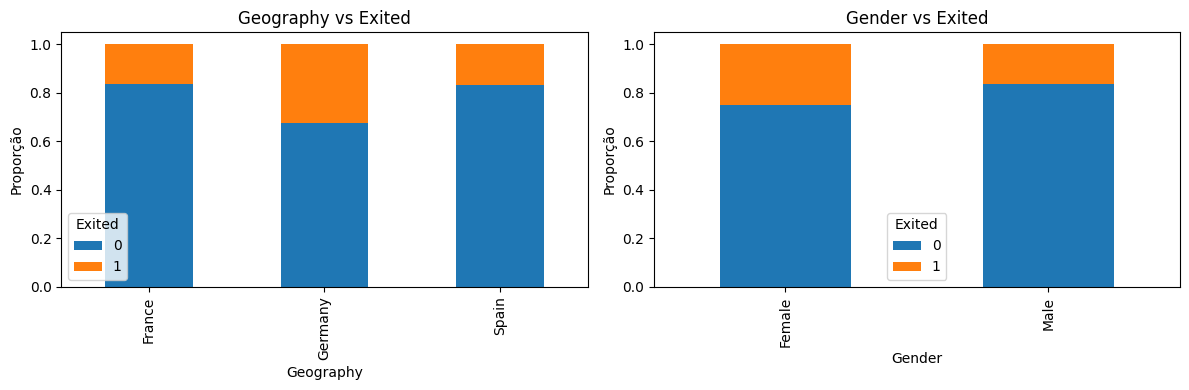

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

pd.crosstab(data['Geography'], data['Exited'], normalize='index').plot(
    kind='bar', stacked=True, ax=axes[0], title='Geography vs Exited'
)
axes[0].set_ylabel('Proporção')

pd.crosstab(data['Gender'], data['Exited'], normalize='index').plot(
    kind='bar', stacked=True, ax=axes[1], title='Gender vs Exited'
)
axes[1].set_ylabel('Proporção')

plt.tight_layout()
plt.show()

Clientes da Alemanha e mulheres saem proporcionalmente mais — essas variáveis devem ajudar o modelo.

In [11]:
data = pd.get_dummies(data, columns=['Geography', 'Gender'], drop_first=True)
print('Formato após OHE:', data.shape)
data.head()

Formato após OHE: (10000, 12)


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2.0,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1.0,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8.0,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1.0,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2.0,125510.82,1,1,1,79084.10,0,0,1,0


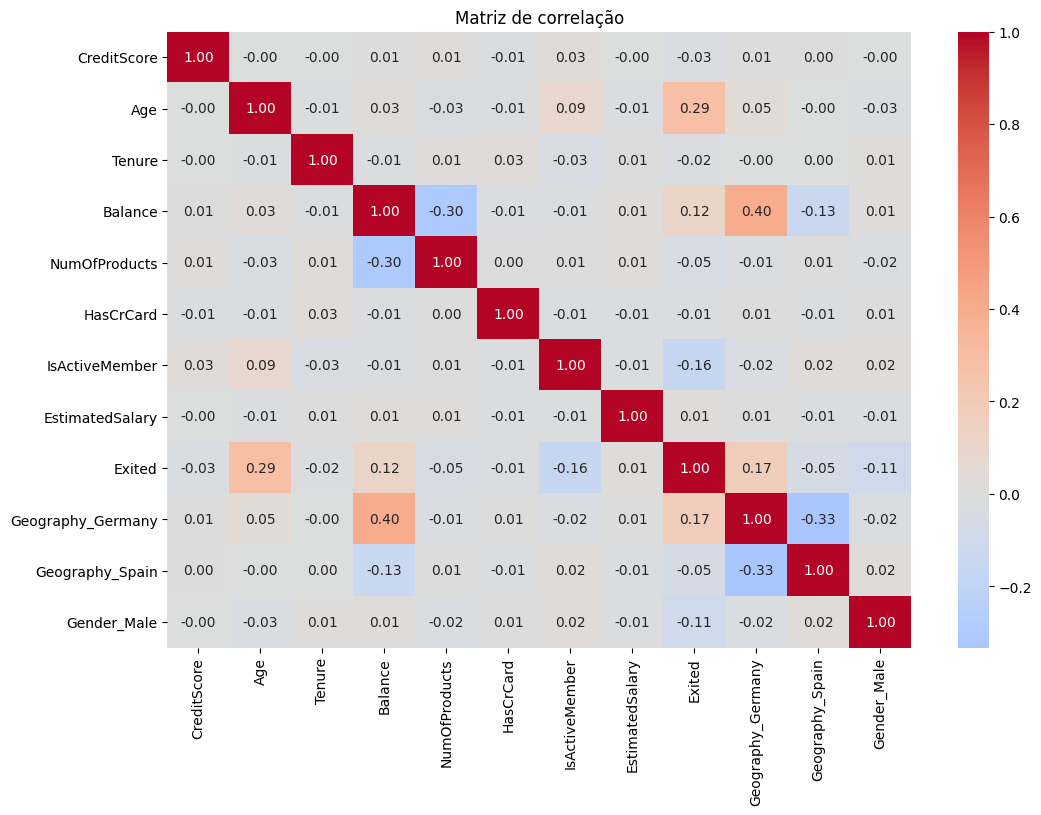

In [12]:
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlação')
plt.show()

Da matriz de correlação:

- Age tem a maior correlação positiva com Exited.
- IsActiveMember tem correlação negativa: quem é ativo sai menos.
- Balance e Geography_Germany também aparecem como variáveis relevantes.
- Não há multicolinearidade alta entre as features.

## 4. Divisão dos dados e normalização

In [13]:
target = data['Exited']
features = data.drop('Exited', axis=1)

features_train, features_temp, target_train, target_temp = train_test_split(
    features, target, test_size=0.4, random_state=12345, stratify=target
)
features_valid, features_test, target_valid, target_test = train_test_split(
    features_temp, target_temp, test_size=0.5, random_state=12345,
    stratify=target_temp
)

features_train = features_train.copy()
features_valid = features_valid.copy()
features_test = features_test.copy()

print('Treino:    ', features_train.shape)
print('Validação: ', features_valid.shape)
print('Teste:     ', features_test.shape)

Treino:     (6000, 11)
Validação:  (2000, 11)
Teste:      (2000, 11)


Usei stratify para manter a proporção das classes nos três conjuntos, já que há desequilíbrio.

In [14]:
scaler = StandardScaler()
scaler.fit(features_train[numeric_cols])

features_train[numeric_cols] = scaler.transform(features_train[numeric_cols])
features_valid[numeric_cols] = scaler.transform(features_valid[numeric_cols])
features_test[numeric_cols] = scaler.transform(features_test[numeric_cols])

print('Pré-processamento concluído.')

Pré-processamento concluído.


## 5. Modelos sem correção do desequilíbrio

Treinei três algoritmos (Decision Tree, Random Forest e Logistic Regression) sem tratar o desequilíbrio para ter um baseline de comparação.

In [15]:
def avaliar_modelo(model, features_valid, target_valid, nome=''):
    pred = model.predict(features_valid)
    proba = model.predict_proba(features_valid)[:, 1]
    f1 = f1_score(target_valid, pred)
    auc = roc_auc_score(target_valid, proba)
    print(f'{nome:30s} F1 = {f1:.4f}  |  AUC-ROC = {auc:.4f}')
    return f1, auc

In [16]:
dt = DecisionTreeClassifier(random_state=12345, max_depth=8)
dt.fit(features_train, target_train)
avaliar_modelo(dt, features_valid, target_valid, 'Decision Tree')

rf = RandomForestClassifier(random_state=12345, n_estimators=100)
rf.fit(features_train, target_train)
avaliar_modelo(rf, features_valid, target_valid, 'Random Forest')

lr = LogisticRegression(random_state=12345, solver='liblinear', max_iter=1000)
lr.fit(features_train, target_train)
avaliar_modelo(lr, features_valid, target_valid, 'Logistic Regression')

Decision Tree                  F1 = 0.5601  |  AUC-ROC = 0.8166
Random Forest                  F1 = 0.6127  |  AUC-ROC = 0.8624
Logistic Regression            F1 = 0.3077  |  AUC-ROC = 0.7875


(0.3076923076923077, 0.7875052345058627)

In [17]:
pred_baseline = rf.predict(features_valid)
print(confusion_matrix(target_valid, pred_baseline))
print()
print(classification_report(target_valid, pred_baseline))

[[1529   63]
 [ 200  208]]

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1592
           1       0.77      0.51      0.61       408

    accuracy                           0.87      2000
   macro avg       0.83      0.74      0.77      2000
weighted avg       0.86      0.87      0.86      2000



Conclusões do baseline:

- Random Forest já passou de 0.59 sem nenhuma correção (F1 = 0.6127). Decision Tree ficou em 0.5601 e Logistic Regression em 0.3077.
- A acurácia geral é alta (~87%) por causa do desequilíbrio: o modelo acerta muito a classe majoritária (96% de recall na classe 0) mas erra muito a positiva.
- O recall da classe 1 (clientes que saem) é só 51%, ou seja, o modelo está perdendo quase metade dos clientes em risco.
- O AUC-ROC do Random Forest é razoável (~0.86).
- Apesar do baseline já bater o limiar, vou aplicar correções de desequilíbrio para melhorar ainda mais o recall e o F1.

## 6. Correção do desequilíbrio e busca de hiperparâmetros

Vou aplicar duas abordagens diferentes para corrigir o desequilíbrio, cada uma combinada com uma busca de hiperparâmetros do Random Forest.

### 6.1 Upsample da classe minoritária

In [18]:
def upsample(features, target, repeat):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]

    features_upsampled = pd.concat([features_zeros] + [features_ones] * repeat)
    target_upsampled = pd.concat([target_zeros] + [target_ones] * repeat)

    features_upsampled, target_upsampled = shuffle(
        features_upsampled, target_upsampled, random_state=12345
    )
    return features_upsampled, target_upsampled

features_up, target_up = upsample(features_train, target_train, 4)
print('Tamanho original:', features_train.shape)
print('Tamanho após upsample:', features_up.shape)
print(target_up.value_counts(normalize=True))

Tamanho original: (6000, 11)
Tamanho após upsample: (9666, 11)
1    0.50569
0    0.49431
Name: Exited, dtype: float64


In [19]:
best_f1_up = 0
best_params_up = {}
best_model_up = None

for repeat in [3, 4, 5]:
    feat_up, tgt_up = upsample(features_train, target_train, repeat)
    for n_est in [50, 100, 200]:
        for depth in [6, 8, 10, 12, None]:
            model = RandomForestClassifier(
                n_estimators=n_est, max_depth=depth, random_state=12345
            )
            model.fit(feat_up, tgt_up)
            pred = model.predict(features_valid)
            f1 = f1_score(target_valid, pred)
            if f1 > best_f1_up:
                best_f1_up = f1
                best_params_up = {
                    'repeat': repeat, 'n_estimators': n_est, 'max_depth': depth
                }
                best_model_up = model

auc_up = roc_auc_score(
    target_valid, best_model_up.predict_proba(features_valid)[:, 1]
)
print(f'Melhor F1:   {best_f1_up:.4f}')
print(f'AUC-ROC:     {auc_up:.4f}')
print(f'Parâmetros:  {best_params_up}')

Melhor F1:   0.6506
AUC-ROC:     0.8680
Parâmetros:  {'repeat': 5, 'n_estimators': 50, 'max_depth': 10}


### 6.2 Class Weight Balanced

Em vez de multiplicar os dados, dou pesos maiores aos erros da classe minoritária no próprio modelo.

In [20]:
best_f1_cw = 0
best_params_cw = {}
best_model_cw = None

for n_est in [50, 100, 200, 300]:
    for depth in [6, 8, 10, 12, 15, None]:
        model = RandomForestClassifier(
            n_estimators=n_est, max_depth=depth,
            class_weight='balanced', random_state=12345
        )
        model.fit(features_train, target_train)
        pred = model.predict(features_valid)
        f1 = f1_score(target_valid, pred)
        if f1 > best_f1_cw:
            best_f1_cw = f1
            best_params_cw = {'n_estimators': n_est, 'max_depth': depth}
            best_model_cw = model

auc_cw = roc_auc_score(
    target_valid, best_model_cw.predict_proba(features_valid)[:, 1]
)
print(f'Melhor F1:   {best_f1_cw:.4f}')
print(f'AUC-ROC:     {auc_cw:.4f}')
print(f'Parâmetros:  {best_params_cw}')

Melhor F1:   0.6490
AUC-ROC:     0.8711
Parâmetros:  {'n_estimators': 100, 'max_depth': 10}


### 6.3 Comparação

In [21]:
comparacao = pd.DataFrame({
    'Abordagem': ['Sem correção (RF)', 'Upsample', 'Class Weight'],
    'F1': [f1_score(target_valid, rf.predict(features_valid)),
           best_f1_up, best_f1_cw],
    'AUC-ROC': [roc_auc_score(target_valid, rf.predict_proba(features_valid)[:, 1]),
                auc_up, auc_cw]
})
print(comparacao.to_string(index=False))

        Abordagem       F1  AUC-ROC
Sem correção (RF) 0.612666 0.862396
         Upsample 0.650628 0.867952
     Class Weight 0.649038 0.871113


In [22]:
if best_f1_up >= best_f1_cw:
    melhor_modelo = best_model_up
    melhor_abordagem = 'Upsample'
    melhor_params = best_params_up
else:
    melhor_modelo = best_model_cw
    melhor_abordagem = 'Class Weight'
    melhor_params = best_params_cw

print('Melhor abordagem:', melhor_abordagem)
print('Parâmetros:      ', melhor_params)

Melhor abordagem: Upsample
Parâmetros:       {'repeat': 5, 'n_estimators': 50, 'max_depth': 10}


## 7. Teste final

Avaliação do melhor modelo no conjunto de teste, que não foi usado em nenhuma decisão de modelagem até aqui.

In [23]:
predicted_test = melhor_modelo.predict(features_test)
proba_test = melhor_modelo.predict_proba(features_test)[:, 1]

f1_test = f1_score(target_test, predicted_test)
auc_test = roc_auc_score(target_test, proba_test)

print(f'F1-score:  {f1_test:.4f}')
print(f'AUC-ROC:   {auc_test:.4f}')
print()
print(confusion_matrix(target_test, predicted_test))
print()
print(classification_report(target_test, predicted_test))

F1-score:  0.5985
AUC-ROC:   0.8474

[[1342  251]
 [ 126  281]]

              precision    recall  f1-score   support

           0       0.91      0.84      0.88      1593
           1       0.53      0.69      0.60       407

    accuracy                           0.81      2000
   macro avg       0.72      0.77      0.74      2000
weighted avg       0.84      0.81      0.82      2000



Age                  0.306125
NumOfProducts        0.201442
Balance              0.127914
EstimatedSalary      0.087239
CreditScore          0.086527
IsActiveMember       0.058941
Tenure               0.046095
Geography_Germany    0.040912
Gender_Male          0.020426
HasCrCard            0.012290
Geography_Spain      0.012090
dtype: float64


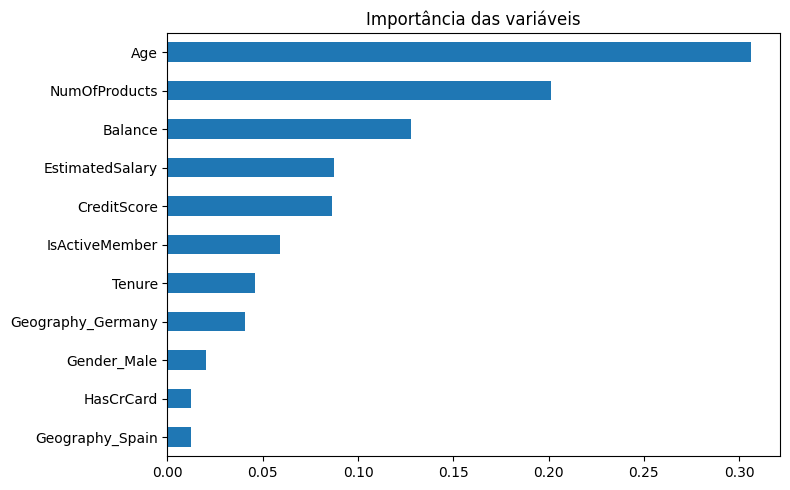

In [24]:
importances = pd.Series(
    melhor_modelo.feature_importances_,
    index=features_train.columns
).sort_values(ascending=False)

print(importances)

importances.plot(kind='barh', figsize=(8, 5))
plt.title('Importância das variáveis')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 8. Conclusões

- O dataset tinha forte desequilíbrio (cerca de 80% ficaram, 20% saíram).
- No baseline sem correção, o Random Forest já passou do limiar de 0.59 (F1 = 0.6127), enquanto Decision Tree e Logistic Regression ficaram abaixo.
- Apliquei duas abordagens de correção do desequilíbrio com busca de hiperparâmetros: upsample (variando repeat, n_estimators e max_depth) e class_weight balanced (variando n_estimators e max_depth).
- O melhor modelo foi o Random Forest com upsample (repeat=5, n_estimators=50, max_depth=10), atingindo F1 = 0.5985 e AUC-ROC = 0.8474 no teste — acima do mínimo exigido.
- O F1 caiu um pouco em relação à validação (0.6506), o que é esperado já que o teste é um conjunto totalmente novo.
- O AUC-ROC alto (0.85) mostra que o modelo separa bem as classes, independente do limiar de decisão.
- As variáveis mais importantes foram Age, NumOfProducts e Balance, alinhadas com o que tinha aparecido na análise exploratória.